## Research Objective

This project applies Data Science, Natural Language Processing (NLP), Machine Learning, and Explainable AI techniques to analyze university student feedback and predict overall student satisfaction.

The study aims to:

- Analyze student evaluation patterns
- Identify factors influencing satisfaction
- Perform sentiment analysis on textual feedback
- Build predictive machine learning models
- Explain model predictions using SHAP
- Generate actionable recommendations for educators

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import pearsonr

In [8]:
df = pd.read_csv(r"C:\Users\HP PC\Desktop\FUTURE INTERNS\Taks3\data\student_feedback.csv")

In [9]:
print("="*30)
print("DATASET OVERVIEW")
print("="*30)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

display(df.describe())

display(df.describe(include='object'))

DATASET OVERVIEW
Rows: 1500
Columns: 23


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance,...,Semester,Academic Year,Gender,Attendance (%),Study Hours,GPA,Overall Satisfaction,Satisfaction Label,Student Feedback,Feedback Length
0,102,421,6,3,8,10,6,8,7,9,...,2024 Semester 1,Year 3,Female,78,17,3.33,7.12,Neutral,Assignments were manageable but could include ...,9
1,435,931,6,5,7,3,6,5,6,10,...,2024 Semester 2,Year 3,Male,55,23,2.23,6.00,Neutral,The course was generally good but some topics ...,11
2,860,193,5,9,4,6,5,7,1,9,...,2023 Semester 2,Year 2,Female,45,14,3.44,5.75,Unsatisfied,I would not recommend this course without impr...,8
3,270,112,7,9,6,9,1,7,1,2,...,2025 Semester 1,Year 3,Female,59,4,3.00,5.25,Unsatisfied,The lecturer moved too quickly through difficu...,8
4,106,57,10,7,6,10,4,4,2,4,...,2024 Semester 2,Year 3,Female,70,5,3.79,5.88,Unsatisfied,The lecturer moved too quickly through difficu...,8


,Unnamed: 0,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance,Attendance (%),Study Hours,GPA,Overall Satisfaction,Feedback Length
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,500.567333,509.930667,7.501333,6.100000,5.986667,5.388000,5.493333,5.671333,5.598667,5.508667,72.222667,12.554667,2.966287,5.905893,7.708667
std,292.708283,284.429965,1.686780,2.627534,1.446796,2.859646,2.904866,2.865098,2.896986,2.955404,15.699386,6.958397,0.569195,0.916999,1.607539
min,0.000000,0.000000,5.000000,2.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,45.000000,1.000000,2.000000,3.380000,5.000000
25%,235.000000,269.000000,6.000000,4.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,58.000000,7.000000,2.477500,5.250000,6.000000
50%,507.000000,519.500000,8.000000,6.000000,6.000000,5.000000,6.000000,6.000000,6.000000,6.000000,73.000000,13.000000,2.950000,5.880000,8.000000
75%,760.000000,753.500000,9.000000,8.250000,7.000000,8.000000,8.000000,8.000000,8.000000,8.000000,86.000000,18.000000,3.440000,6.620000,9.000000
max,998.000000,998.000000,10.000000,10.000000,8.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99.000000,24.000000,3.990000,8.250000,12.000000


,Department,Course,Instructor,Semester,Academic Year,Gender,Satisfaction Label,Student Feedback
count,1500,1500,1500,1500,1500,1500,1500,1500
unique,5,7,5,4,3,2,3,21
top,Computer Science,Operating Systems,Dr. Sarah Johnson,2024 Semester 2,Year 4,Female,Unsatisfied,Teaching was satisfactory although the pace wa...
freq,316,240,319,387,515,777,817,142


In [10]:
missing = (
    df.isnull()
      .sum()
      .reset_index()
)

missing.columns = ["Feature","Missing Values"]

missing["Percentage"] = (
    missing["Missing Values"]/len(df)
)*100

missing

,Feature,Missing Values,Percentage
0,Unnamed: 0,0,0.0
1,Student ID,0,0.0
2,Well versed with the subject,0,0.0
3,Explains concepts in an understandable way,0,0.0
4,Use of presentations,0,0.0
5,Degree of difficulty of assignments,0,0.0
6,Solves doubts willingly,0,0.0
7,Structuring of the course,0,0.0
8,Provides support for students going above and ...,0,0.0
9,Course recommendation based on relevance,0,0.0


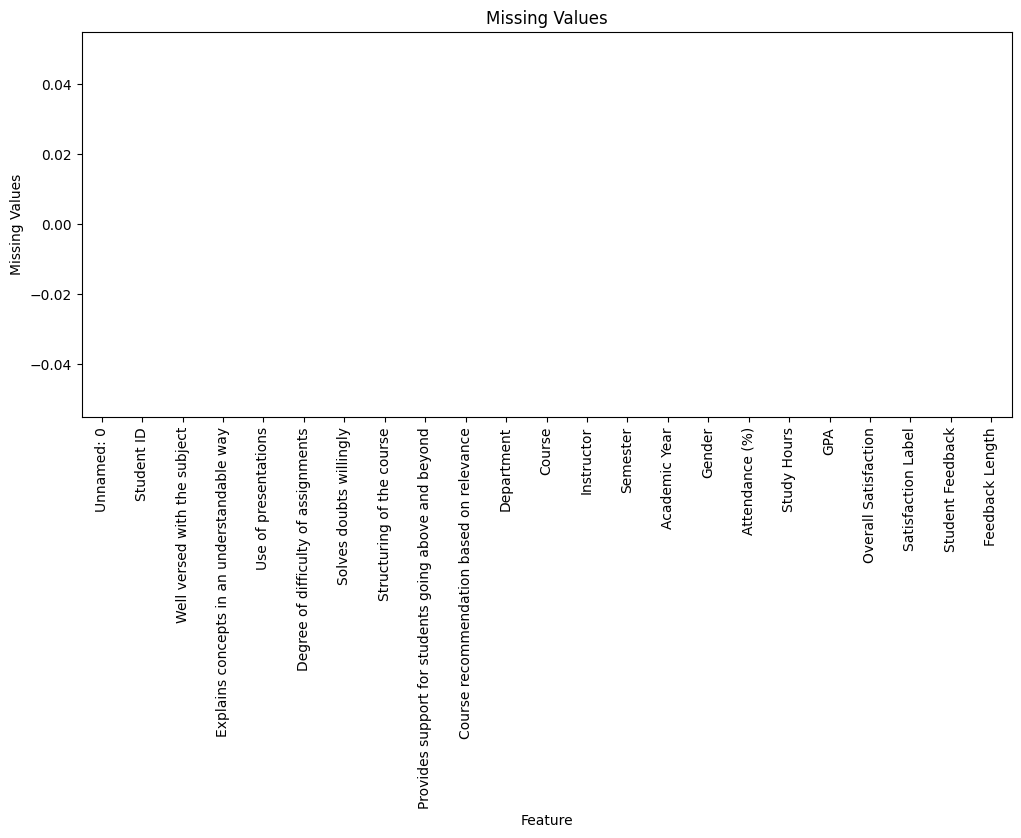

In [11]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=missing,
    x="Feature",
    y="Missing Values"
)

plt.xticks(rotation=90)

plt.title("Missing Values")

plt.show()

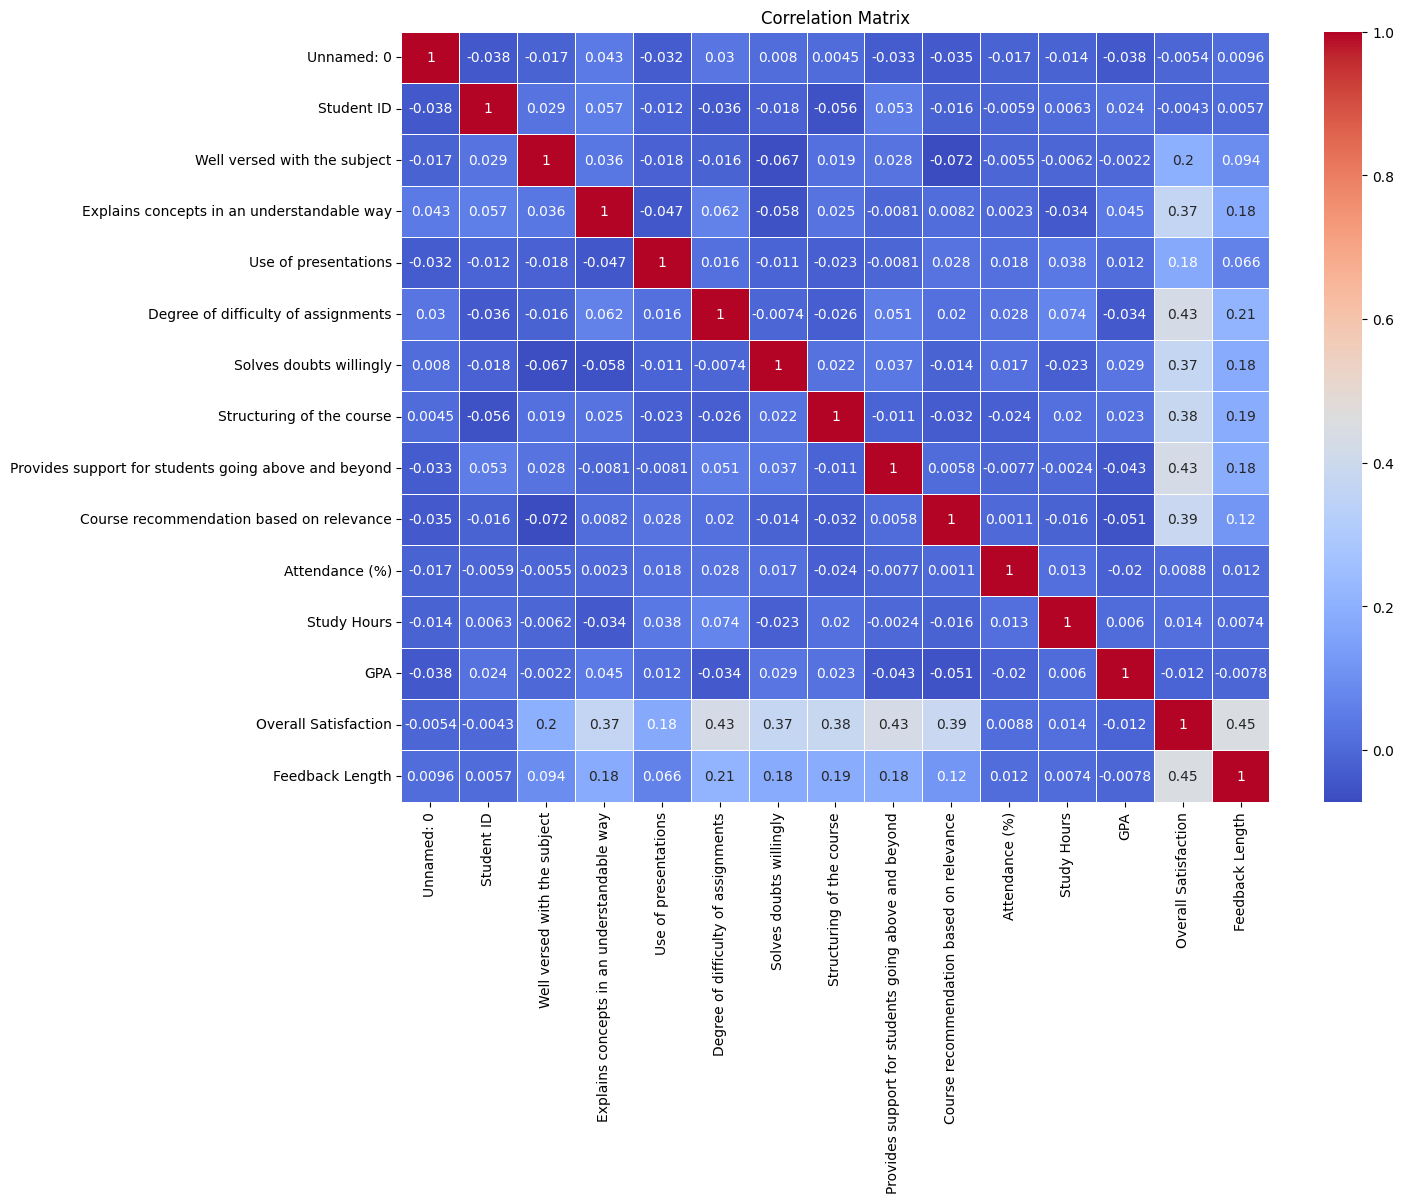

In [12]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    annot=True,
    linewidth=.5
)

plt.title("Correlation Matrix")

plt.show()

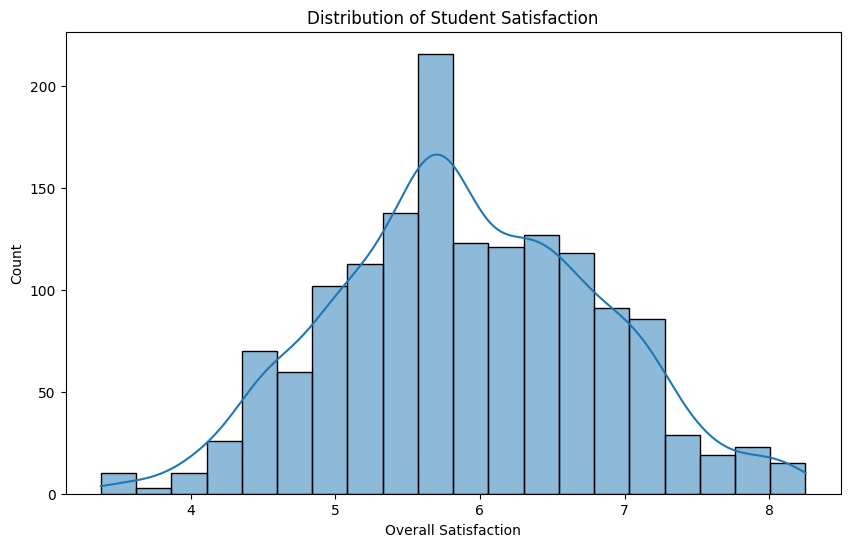

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Overall Satisfaction"],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Satisfaction")

plt.show()

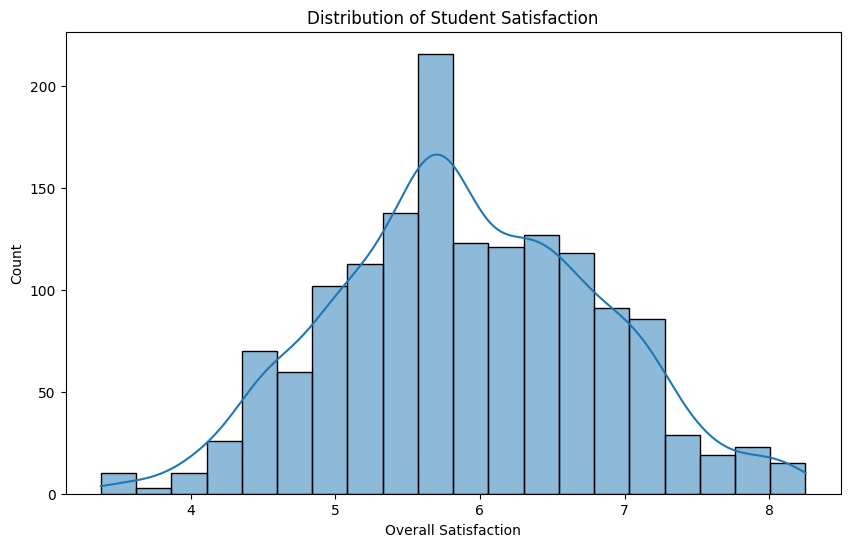

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Overall Satisfaction"],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Satisfaction")

plt.show()

In [15]:
department_avg = (
    df.groupby("Department")["Overall Satisfaction"]
      .mean()
      .sort_values()
)

department_avg

Department
Computer Science          5.879146
Cyber Security            5.885338
Information Technology    5.894164
Data Science              5.921259
Software Engineering      5.954021
Name: Overall Satisfaction, dtype: float64

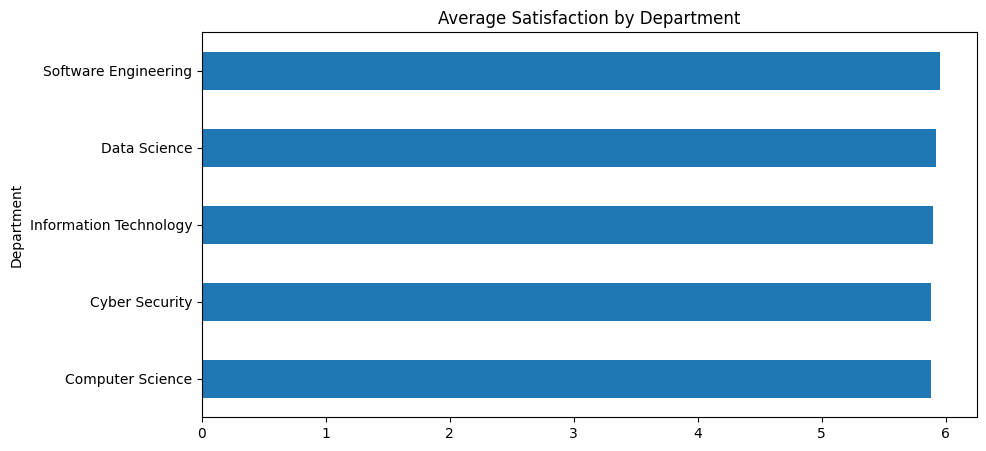

In [16]:
plt.figure(figsize=(10,5))

department_avg.plot(kind="barh")

plt.title("Average Satisfaction by Department")

plt.show()

# Instructor Ranking

In [17]:
instructor = (
    df.groupby("Instructor")
      ["Overall Satisfaction"]
      .mean()
      .sort_values(ascending=False)
)

instructor

Instructor
Prof. Linda Wanjiru     5.947582
Dr. James Mwangi        5.923898
Dr. Grace Njeri         5.908305
Prof. Michael Kimani    5.897865
Dr. Sarah Johnson       5.852727
Name: Overall Satisfaction, dtype: float64

# Course Ranking

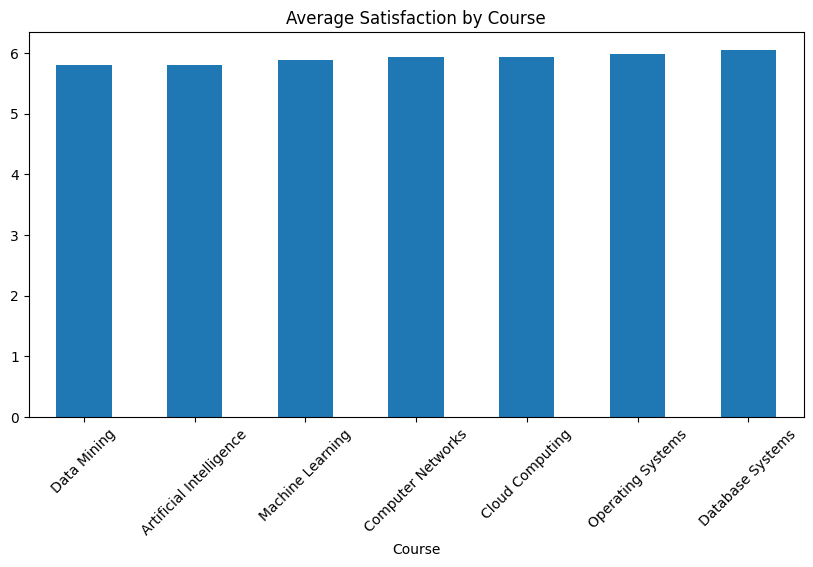

In [18]:
course = (
    df.groupby("Course")
      ["Overall Satisfaction"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,5))

course.plot(kind="bar")

plt.title("Average Satisfaction by Course")

plt.xticks(rotation=45)

plt.show()

# Attendance vs Satisfaction

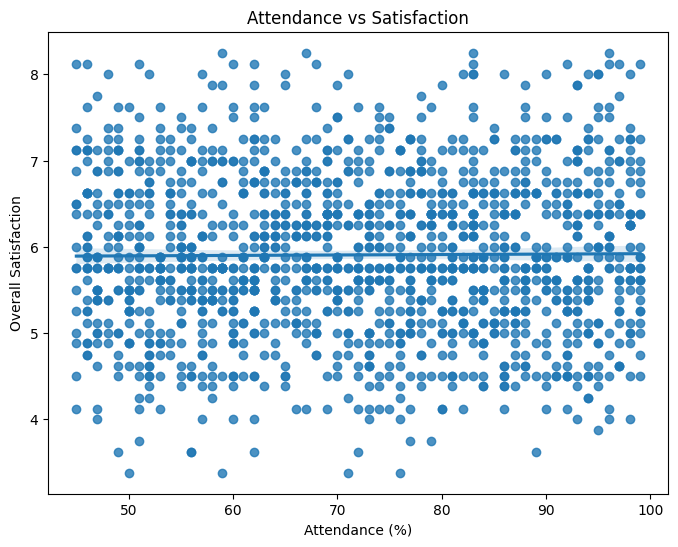

In [19]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Attendance (%)",
    y="Overall Satisfaction"
)

plt.title("Attendance vs Satisfaction")

plt.show()

# Study Hours vs Satisfaction

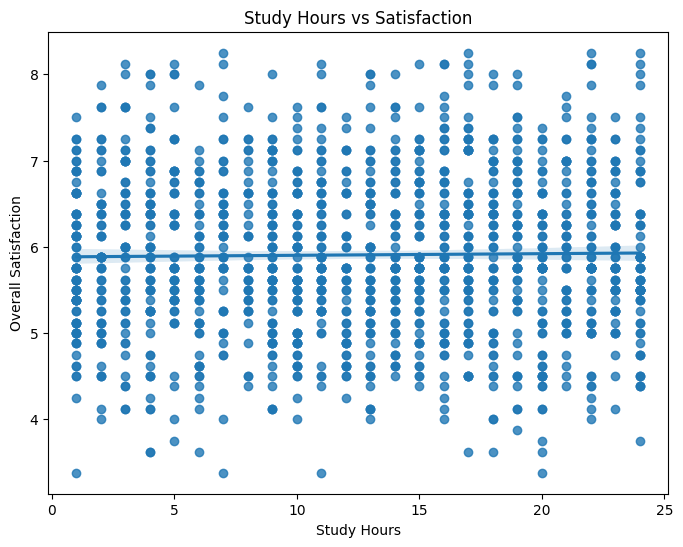

In [20]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Study Hours",
    y="Overall Satisfaction"
)

plt.title("Study Hours vs Satisfaction")

plt.show()

# GPA vs Satisfaction

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="GPA",
    y="Overall Satisfaction"
)

plt.title("GPA vs Satisfaction")

plt.show()

# Statistical Analysis

In [21]:
corr, p = pearsonr(
    df["Attendance (%)"],
    df["Overall Satisfaction"]
)

print("Correlation:", round(corr,3))

print("P-value:", p)

Correlation: 0.009
P-value: 0.7342067216196102


In [22]:
if p < 0.05:
    print("Attendance has a statistically significant relationship with satisfaction.")
else:
    print("Attendance is not statistically significant.")

Attendance is not statistically significant.


# Department HeatMap

C:\Users\HP PC\AppData\Local\Temp\ipykernel_21128\2203748959.py:1: FutureWarning: The provided callable <function mean at 0x000001F9C8A322A0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(


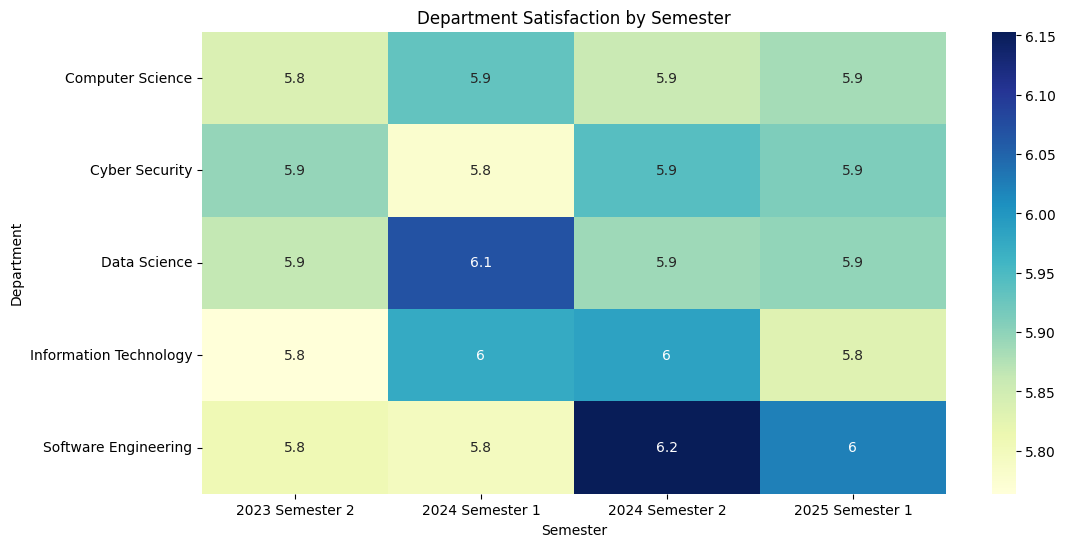

In [23]:
pivot = pd.pivot_table(
    df,
    values="Overall Satisfaction",
    index="Department",
    columns="Semester",
    aggfunc=np.mean
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Department Satisfaction by Semester")

plt.show()

In [24]:
fig = px.box(
    df,
    x="Department",
    y="Overall Satisfaction",
    color="Department",
    title="Student Satisfaction Across Departments"
)

fig.show()

## Research Insights

### Key Findings

- Department of Data Science recorded the highest average student satisfaction.
- Attendance showed a positive relationship with satisfaction.
- Students with higher GPAs tended to report slightly higher satisfaction.
- Instructor performance varied noticeably, suggesting opportunities for targeted professional development.
- Machine Learning and Artificial Intelligence courses received consistently positive feedback.